# Vega-Lite is declarative; Matplotlib is imperative

Vega-Lite specs say *what* a plot is: a dataset, a mark type, a few encoding channels. Matplotlib code says *how* to draw it: figures, axes, calls to `bar` / `scatter` / `plot`, legends. This post walks through a small Python translator that lowers Vega-Lite JSON onto plain Matplotlib code so you can paste the output into a script.

A few reasons that's useful:

- Authors generate Vega-Lite via Altair / Observable / dashboards, then need plain Matplotlib to drop the figure into a LaTeX paper.
- Vega-Lite is a great way to *describe* a plot. Matplotlib code is a great way to *edit* a plot — fonts, ticks, twin axes, callouts.
- It's a fun, short compiler exercise.

This is **v2**. The first cut was a single function with `if mark == "bar": ...` branches. That's fine for five marks, but the moment you want layering (multiple marks on one axes), faceting (small multiples), or `aggregate: "mean"`, the function turns into a hairball. The visitor pattern fixes that: one method per node type, recursing into children, returning emitted code lines.

What v2 supports:

- marks: **bar, point, circle, line, area, tick**
- encodings: **x, y, color, size, opacity** (plus optional `title` per channel)
- aggregations: **mean, sum, count, median, min, max** on x or y
- scales: **log** axes and explicit **domain**
- containers: **layer** (overlay), **column / row faceting** (small multiples)
- transforms: **filter** (`"datum.x > 5"` style)

What it still won't do: `hconcat`/`vconcat` of unlike specs, time scales, named color schemes, tooltips/selections. Those would be straightforward additions to the visitor — just more methods.

## Setup

Altair to render the original specs, Matplotlib to render the translated ones, pandas because it's how Matplotlib likes to receive tabular data.

In [1]:
import json

import altair as alt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

%matplotlib inline
%config InlineBackend.figure_format = "retina"

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 220,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

alt.data_transformers.disable_max_rows()
print("altair", alt.__version__)

altair 6.0.0


## The visitor class

The translator is a class that builds up a list of code lines. Public entry point is `code()`. Internally:

- `visit(spec)` is the **top-level dispatch**: it picks `visit_layer`, `visit_facet`, or `visit_unit` based on the shape of the spec.
- Mark dispatch happens via `getattr(self, f"visit_mark_{mark}")` — adding a new mark is just adding a method.
- `_emit_*` helpers handle data, transforms, and axes — shared across all unit-level paths.
- `emit(...)` and `push_indent()` / `pop_indent()` keep the output readable.

The whole class fits in roughly 200 lines, and `vegalite_to_matplotlib(spec)` is just a thin wrapper around `VegaLiteToMatplotlib(spec).code()` so the v1 calling convention still works.

In [2]:
SUPPORTED_AGGREGATES = {"mean", "sum", "count", "median", "min", "max"}


def _mark_type(spec):
    mark = spec.get("mark")
    return mark if isinstance(mark, str) else mark.get("type")


def _enc_label(enc_channel):
    if "title" in enc_channel:
        return enc_channel["title"]
    if "aggregate" in enc_channel and enc_channel.get("field"):
        return f"{enc_channel['aggregate']}({enc_channel['field']})"
    return enc_channel.get("field", "")


def _has_facet(spec):
    enc = spec.get("encoding", {})
    return "column" in enc or "row" in enc or "facet" in spec


class VegaLiteToMatplotlib:
    """Recursive Vega-Lite -> Matplotlib code translator.

    Dispatch:
      top-level    -> visit_layer | visit_facet | visit_unit
      mark         -> visit_mark_bar | visit_mark_point | visit_mark_circle
                       | visit_mark_line | visit_mark_area | visit_mark_tick
    """

    def __init__(self, spec):
        self.spec = spec
        self._lines = []
        self._indent = 0

    # --- emit / indent ---

    def emit(self, *lines):
        for line in lines:
            self._lines.append(("    " * self._indent + line) if line else "")

    def push_indent(self):
        self._indent += 1

    def pop_indent(self):
        self._indent -= 1

    # --- entry point ---

    def code(self):
        if self._lines:
            return "\n".join(self._lines)

        self.emit("import matplotlib.pyplot as plt")
        self.emit("import numpy as np")
        self.emit("import pandas as pd")
        self.emit("")

        spec = self.spec
        if _has_facet(spec):
            self.visit_facet(spec)
        elif "layer" in spec:
            self.emit("fig, ax = plt.subplots(figsize=(6, 3.6))")
            self.emit("")
            self.visit_layer(spec, ax_expr="ax")
            self.emit("fig.tight_layout()")
        else:
            self.emit("fig, ax = plt.subplots(figsize=(6, 3.6))")
            self.emit("")
            self.visit_unit(spec, ax_expr="ax")
            self.emit("fig.tight_layout()")

        self.emit("plt.show()")
        return "\n".join(self._lines)

    # --- top-level visitors ---

    def visit_unit(self, spec, ax_expr, df_expr=None):
        if df_expr is None:
            df_expr = "df"
            self._emit_data(spec, df_expr)
            self._emit_transforms(spec, df_expr)
        self._dispatch_mark(spec, ax_expr, df_expr)
        self._emit_axes(spec, ax_expr)

    def visit_layer(self, spec, ax_expr):
        outer_data = spec.get("data")
        for i, layer in enumerate(spec["layer"]):
            df_var = f"df_layer_{i}"
            inner = dict(layer)
            inner.setdefault("data", outer_data)
            self._emit_data(inner, df_var)
            self._emit_transforms(inner, df_var)
            self._dispatch_mark(inner, ax_expr, df_var)
        # axes from the first layer
        self._emit_axes(spec["layer"][0], ax_expr)
        if spec.get("title"):
            self.emit(f"{ax_expr}.set_title({_unwrap_title(spec['title'])!r})")

    def visit_facet(self, spec):
        enc = spec.get("encoding", {})
        col_field = enc.get("column", {}).get("field")
        row_field = enc.get("row", {}).get("field")
        if col_field is None and row_field is None:
            raise NotImplementedError("Facet requires column or row encoding")
        if col_field and row_field:
            raise NotImplementedError("2D faceting (column AND row) not implemented")

        self._emit_data(spec, "df")
        self._emit_transforms(spec, "df")

        facet_field = col_field or row_field
        is_column = col_field is not None
        self.emit(f"facet_values = list(dict.fromkeys(df[{facet_field!r}]))")
        if is_column:
            self.emit("fig, axes = plt.subplots(")
            self.emit("    1, len(facet_values),")
            self.emit("    figsize=(3.0 * len(facet_values), 3.2),")
            self.emit("    sharey=True,")
            self.emit(")")
        else:
            self.emit("fig, axes = plt.subplots(")
            self.emit("    len(facet_values), 1,")
            self.emit("    figsize=(5.0, 2.6 * len(facet_values)),")
            self.emit("    sharex=True,")
            self.emit(")")
        self.emit("if len(facet_values) == 1:")
        self.push_indent(); self.emit("axes = [axes]"); self.pop_indent()

        self.emit("for ax, facet_val in zip(axes, facet_values):")
        self.push_indent()
        self.emit(f"sub = df[df[{facet_field!r}] == facet_val]")
        inner = dict(spec)
        inner_enc = dict(enc)
        inner_enc.pop("column", None)
        inner_enc.pop("row", None)
        inner["encoding"] = inner_enc
        inner.pop("data", None)
        self.visit_unit(inner, ax_expr="ax", df_expr="sub")
        self.emit(f"ax.set_title(f'{facet_field}={{facet_val}}')")
        self.pop_indent()
        self.emit("fig.tight_layout()")

    # --- data / transforms ---

    def _emit_data(self, spec, df_var):
        data = spec.get("data") or {}
        if "values" in data:
            self.emit(f"{df_var} = pd.DataFrame({json.dumps(data['values'])})")
        elif "url" in data:
            self.emit(f"{df_var} = pd.read_json({data['url']!r})")
        elif "name" in data:
            self.emit(f"# expecting a name-bound dataset {data['name']!r}")
            self.emit(f"{df_var} = pd.DataFrame()")
        else:
            self.emit(f"{df_var} = pd.DataFrame()  # spec has no data")

    def _emit_transforms(self, spec, df_var):
        for t in spec.get("transform", []):
            if "filter" in t and isinstance(t["filter"], str):
                py_expr = t["filter"].replace("datum.", f"{df_var}.")
                self.emit(f"{df_var} = {df_var}[{py_expr}].reset_index(drop=True)")
            else:
                self.emit(f"# unsupported transform skipped: {t}")

    # --- mark dispatch ---

    def _dispatch_mark(self, spec, ax_expr, df_expr):
        mark = _mark_type(spec)
        method = getattr(self, f"visit_mark_{mark}", None)
        if method is None:
            raise NotImplementedError(f"mark {mark!r} not supported")
        method(spec, ax_expr, df_expr)

    # --- mark visitors ---

    def visit_mark_bar(self, spec, ax_expr, df_expr):
        enc = spec["encoding"]
        x_field = enc["x"].get("field")
        y_field = enc["y"].get("field")
        x_agg = enc["x"].get("aggregate")
        y_agg = enc["y"].get("aggregate")
        color_field = enc.get("color", {}).get("field")

        if y_agg in SUPPORTED_AGGREGATES and not x_agg:
            self._emit_aggregated_bar(df_expr, ax_expr, x_field, y_field, y_agg,
                                       horizontal=False, color_field=color_field)
            return
        if x_agg in SUPPORTED_AGGREGATES and not y_agg:
            self._emit_aggregated_bar(df_expr, ax_expr, y_field, x_field, x_agg,
                                       horizontal=True, color_field=color_field)
            return

        if color_field is None:
            self.emit(f"{ax_expr}.bar({df_expr}[{x_field!r}], {df_expr}[{y_field!r}])")
            return

        self.emit(f"groups = list(dict.fromkeys({df_expr}[{color_field!r}]))")
        self.emit(f"x_vals = list(dict.fromkeys({df_expr}[{x_field!r}]))")
        self.emit("x_idx = np.arange(len(x_vals))")
        self.emit("width = 0.8 / max(1, len(groups))")
        self.emit("for i, g in enumerate(groups):")
        self.push_indent()
        self.emit(f"sub = {df_expr}[{df_expr}[{color_field!r}] == g]")
        self.emit(f"ys = [sub[sub[{x_field!r}] == xv][{y_field!r}].sum() for xv in x_vals]")
        self.emit(f"{ax_expr}.bar(x_idx + i * width - 0.4 + width / 2, ys, width, label=str(g))")
        self.pop_indent()
        self.emit(f"{ax_expr}.set_xticks(x_idx)")
        self.emit(f"{ax_expr}.set_xticklabels(x_vals)")
        self.emit(f"{ax_expr}.legend(title={color_field!r})")

    def _emit_aggregated_bar(self, df_expr, ax_expr, group_field, value_field,
                              agg, horizontal, color_field=None):
        if color_field is not None:
            # group by [group, color], pivot, side-by-side bars
            if agg == "count":
                self.emit(
                    f"agg_df = ({df_expr}.groupby([{group_field!r}, {color_field!r}])"
                    ".size().unstack(fill_value=0))"
                )
            else:
                self.emit(
                    f"agg_df = ({df_expr}.groupby([{group_field!r}, {color_field!r}])"
                    f"[{value_field!r}].{agg}().unstack(fill_value=0))"
                )
            self.emit("groups = list(agg_df.columns)")
            self.emit("x_vals = list(agg_df.index)")
            self.emit("x_idx = np.arange(len(x_vals))")
            self.emit("width = 0.8 / max(1, len(groups))")
            self.emit("for i, g in enumerate(groups):")
            self.push_indent()
            offset = "x_idx + i * width - 0.4 + width / 2"
            if horizontal:
                self.emit(f"{ax_expr}.barh({offset}, agg_df[g], width, label=str(g))")
            else:
                self.emit(f"{ax_expr}.bar({offset}, agg_df[g], width, label=str(g))")
            self.pop_indent()
            if horizontal:
                self.emit(f"{ax_expr}.set_yticks(x_idx)")
                self.emit(f"{ax_expr}.set_yticklabels(x_vals)")
            else:
                self.emit(f"{ax_expr}.set_xticks(x_idx)")
                self.emit(f"{ax_expr}.set_xticklabels(x_vals)")
            self.emit(f"{ax_expr}.legend(title={color_field!r})")
            return

        if agg == "count":
            self.emit(f"agg_df = {df_expr}.groupby({group_field!r}).size().reset_index(name='value')")
            value_col = "'value'"
        else:
            self.emit(
                f"agg_df = {df_expr}.groupby({group_field!r})[{value_field!r}]"
                f".{agg}().reset_index()"
            )
            value_col = f"{value_field!r}"
        if horizontal:
            self.emit(f"{ax_expr}.barh(agg_df[{group_field!r}], agg_df[{value_col}])")
        else:
            self.emit(f"{ax_expr}.bar(agg_df[{group_field!r}], agg_df[{value_col}])")

    def visit_mark_point(self, spec, ax_expr, df_expr):
        return self._emit_scatter(spec, ax_expr, df_expr)

    def visit_mark_circle(self, spec, ax_expr, df_expr):
        return self._emit_scatter(spec, ax_expr, df_expr)

    def _emit_scatter(self, spec, ax_expr, df_expr):
        enc = spec.get("encoding", {})
        x_field = enc["x"]["field"]
        y_field = enc["y"]["field"]
        color_field = enc.get("color", {}).get("field")
        size_field = enc.get("size", {}).get("field")
        opacity_field = enc.get("opacity", {}).get("field")

        size_arg = ", s=24"
        if size_field:
            size_arg = (
                f", s=({df_expr}[{size_field!r}] / max(1.0, {df_expr}[{size_field!r}]"
                ".max())) * 200 + 8"
            )
        alpha_arg = ""
        if opacity_field:
            alpha_arg = (
                f", alpha=({df_expr}[{opacity_field!r}] / max(1.0, {df_expr}"
                f"[{opacity_field!r}].max())).clip(0, 1)"
            )

        if color_field is None:
            self.emit(
                f"{ax_expr}.scatter({df_expr}[{x_field!r}], {df_expr}[{y_field!r}]"
                f"{size_arg}{alpha_arg})"
            )
            return

        sub_size = ", s=24"
        if size_field:
            sub_size = (
                f", s=(sub[{size_field!r}] / max(1.0, {df_expr}[{size_field!r}]"
                ".max())) * 200 + 8"
            )
        sub_alpha = ""
        if opacity_field:
            sub_alpha = (
                f", alpha=(sub[{opacity_field!r}] / max(1.0, {df_expr}"
                f"[{opacity_field!r}].max())).clip(0, 1)"
            )
        self.emit(f"for label, sub in {df_expr}.groupby({color_field!r}):")
        self.push_indent()
        self.emit(
            f"{ax_expr}.scatter(sub[{x_field!r}], sub[{y_field!r}]"
            f"{sub_size}{sub_alpha}, label=label)"
        )
        self.pop_indent()
        self.emit(f"{ax_expr}.legend(title={color_field!r})")

    def visit_mark_line(self, spec, ax_expr, df_expr):
        enc = spec.get("encoding", {})
        x_field = enc["x"]["field"]
        y_field = enc["y"]["field"]
        color_field = enc.get("color", {}).get("field")
        if color_field is None:
            self.emit(
                f"{ax_expr}.plot({df_expr}[{x_field!r}], {df_expr}[{y_field!r}], marker='o')"
            )
            return
        self.emit(f"for label, sub in {df_expr}.groupby({color_field!r}):")
        self.push_indent()
        self.emit(
            f"{ax_expr}.plot(sub[{x_field!r}], sub[{y_field!r}], marker='o', label=label)"
        )
        self.pop_indent()
        self.emit(f"{ax_expr}.legend(title={color_field!r})")

    def visit_mark_area(self, spec, ax_expr, df_expr):
        enc = spec.get("encoding", {})
        x_field = enc["x"]["field"]
        y_field = enc["y"]["field"]
        color_field = enc.get("color", {}).get("field")
        if color_field is None:
            self.emit(
                f"{ax_expr}.fill_between({df_expr}[{x_field!r}], "
                f"{df_expr}[{y_field!r}], alpha=0.4)"
            )
            self.emit(
                f"{ax_expr}.plot({df_expr}[{x_field!r}], {df_expr}[{y_field!r}])"
            )
            return
        self.emit(f"for label, sub in {df_expr}.groupby({color_field!r}):")
        self.push_indent()
        self.emit(
            f"{ax_expr}.fill_between(sub[{x_field!r}], sub[{y_field!r}], "
            "alpha=0.35, label=label)"
        )
        self.pop_indent()
        self.emit(f"{ax_expr}.legend(title={color_field!r})")

    def visit_mark_tick(self, spec, ax_expr, df_expr):
        enc = spec.get("encoding", {})
        x_field = enc["x"]["field"]
        y_field = enc.get("y", {}).get("field")
        if y_field:
            self.emit(
                f"{ax_expr}.scatter({df_expr}[{x_field!r}], {df_expr}[{y_field!r}], "
                "marker='|', s=180)"
            )
        else:
            self.emit(
                f"{ax_expr}.scatter({df_expr}[{x_field!r}], "
                f"np.zeros(len({df_expr})), marker='|', s=180)"
            )
            self.emit(f"{ax_expr}.set_yticks([])")

    # --- axis decoration ---

    def _emit_axes(self, spec, ax_expr):
        enc = spec.get("encoding", {})
        if "x" in enc:
            self.emit(f"{ax_expr}.set_xlabel({_enc_label(enc['x'])!r})")
            scale = enc["x"].get("scale", {}) or {}
            if scale.get("type") == "log":
                self.emit(f"{ax_expr}.set_xscale('log')")
            if "domain" in scale:
                lo, hi = scale["domain"]
                self.emit(f"{ax_expr}.set_xlim({lo}, {hi})")
        if "y" in enc:
            self.emit(f"{ax_expr}.set_ylabel({_enc_label(enc['y'])!r})")
            scale = enc["y"].get("scale", {}) or {}
            if scale.get("type") == "log":
                self.emit(f"{ax_expr}.set_yscale('log')")
            if "domain" in scale:
                lo, hi = scale["domain"]
                self.emit(f"{ax_expr}.set_ylim({lo}, {hi})")
        if spec.get("title"):
            self.emit(f"{ax_expr}.set_title({_unwrap_title(spec['title'])!r})")


def _unwrap_title(title):
    if isinstance(title, dict):
        return title.get("text", "")
    return title


def vegalite_to_matplotlib(spec):
    """Backward-compatible wrapper around the visitor."""
    return VegaLiteToMatplotlib(spec).code()


def render_generated(code):
    exec(compile(code, "<generated-mpl>", "exec"), {})


def show_side_by_side(spec):
    print("--- generated Matplotlib code ---")
    code = vegalite_to_matplotlib(spec)
    print(code)
    print()
    print("--- Altair render of the original spec ---")
    display(alt.Chart.from_dict(spec).properties(width=320, height=200))
    print("--- Matplotlib render of the generated code ---")
    render_generated(code)

## Example 1: a bar chart

Same as v1 — quick smoke test that the visitor hasn't broken backward compatibility.

--- generated Matplotlib code ---
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

fig, ax = plt.subplots(figsize=(6, 3.6))

df = pd.DataFrame([{"category": "A", "value": 28}, {"category": "B", "value": 55}, {"category": "C", "value": 43}, {"category": "D", "value": 91}, {"category": "E", "value": 81}, {"category": "F", "value": 53}, {"category": "G", "value": 19}, {"category": "H", "value": 87}])
ax.bar(df['category'], df['value'])
ax.set_xlabel('Category')
ax.set_ylabel('Value')
ax.set_title('A bar chart')
fig.tight_layout()
plt.show()

--- Altair render of the original spec ---


alt.Chart(...)

--- Matplotlib render of the generated code ---


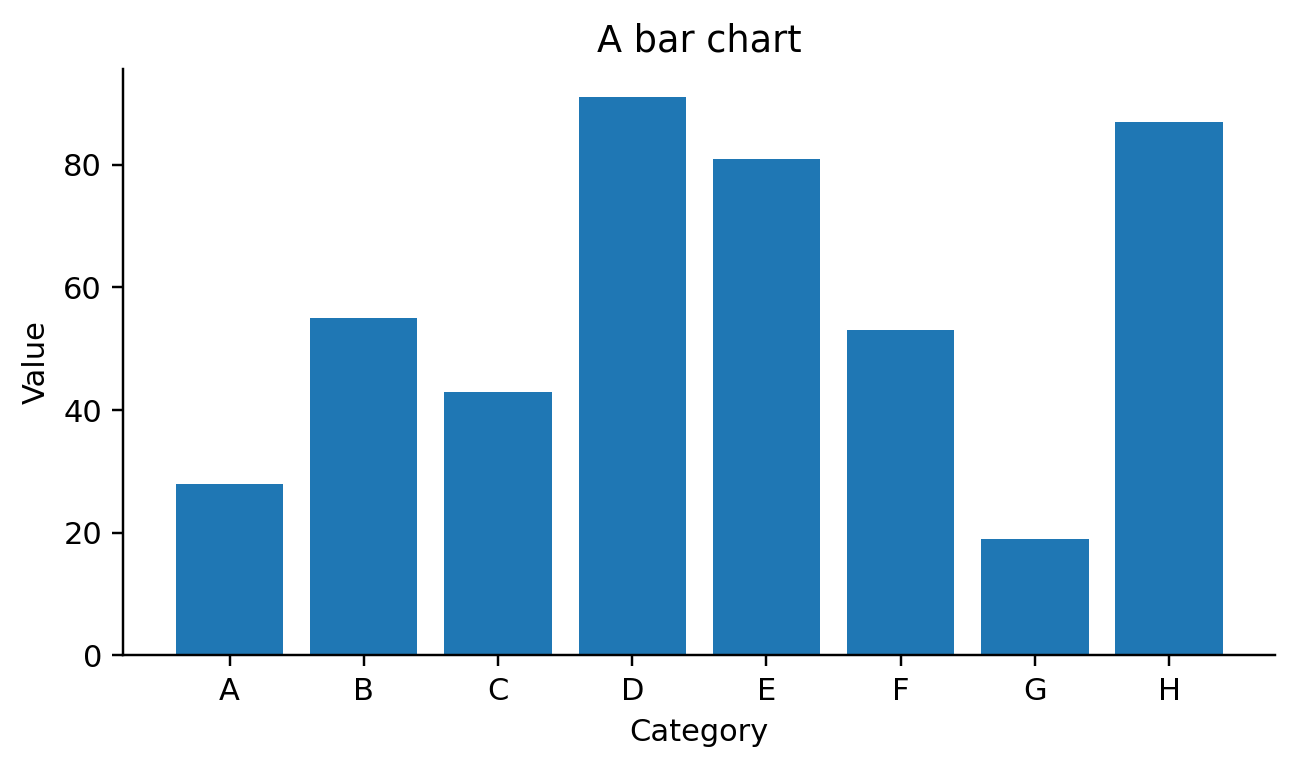

In [3]:
spec_bar = {
    "data": {"values": [
        {"category": "A", "value": 28},
        {"category": "B", "value": 55},
        {"category": "C", "value": 43},
        {"category": "D", "value": 91},
        {"category": "E", "value": 81},
        {"category": "F", "value": 53},
        {"category": "G", "value": 19},
        {"category": "H", "value": 87},
    ]},
    "mark": "bar",
    "encoding": {
        "x": {"field": "category", "type": "nominal", "title": "Category"},
        "y": {"field": "value", "type": "quantitative", "title": "Value"},
    },
    "title": "A bar chart",
}
show_side_by_side(spec_bar)

## Example 2: scatter, no color

--- generated Matplotlib code ---
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

fig, ax = plt.subplots(figsize=(6, 3.6))

df = pd.DataFrame([{"hp": 130, "mpg": 18.0}, {"hp": 165, "mpg": 15.0}, {"hp": 150, "mpg": 18.0}, {"hp": 95, "mpg": 24.0}, {"hp": 70, "mpg": 27.0}, {"hp": 198, "mpg": 14.0}, {"hp": 88, "mpg": 27.0}, {"hp": 215, "mpg": 10.0}, {"hp": 105, "mpg": 22.0}, {"hp": 75, "mpg": 26.0}])
ax.scatter(df['hp'], df['mpg'], s=24)
ax.set_xlabel('Horsepower')
ax.set_ylabel('Miles per gallon')
ax.set_title('Cars: HP vs MPG')
fig.tight_layout()
plt.show()

--- Altair render of the original spec ---


alt.Chart(...)

--- Matplotlib render of the generated code ---


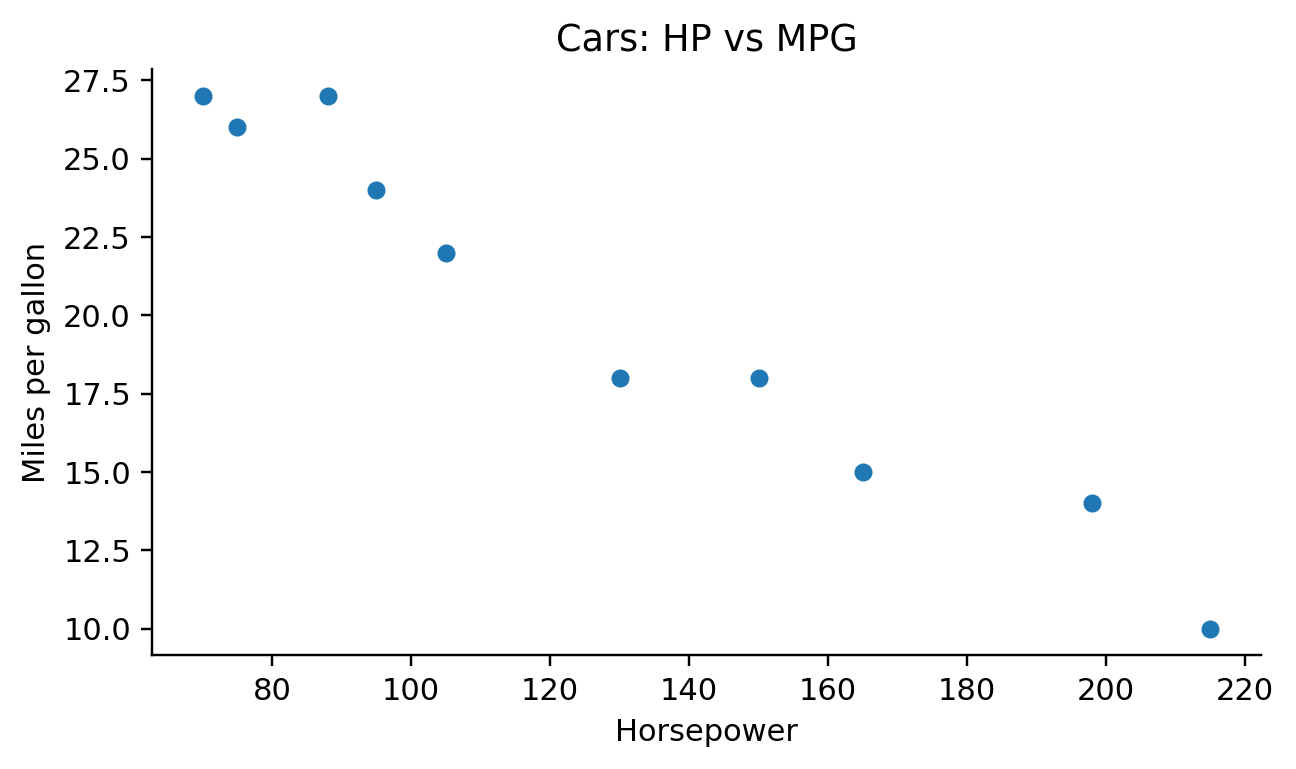

In [4]:
spec_scatter = {
    "data": {"values": [
        {"hp": 130, "mpg": 18.0},
        {"hp": 165, "mpg": 15.0},
        {"hp": 150, "mpg": 18.0},
        {"hp": 95,  "mpg": 24.0},
        {"hp": 70,  "mpg": 27.0},
        {"hp": 198, "mpg": 14.0},
        {"hp": 88,  "mpg": 27.0},
        {"hp": 215, "mpg": 10.0},
        {"hp": 105, "mpg": 22.0},
        {"hp": 75,  "mpg": 26.0},
    ]},
    "mark": "point",
    "encoding": {
        "x": {"field": "hp", "type": "quantitative", "title": "Horsepower"},
        "y": {"field": "mpg", "type": "quantitative", "title": "Miles per gallon"},
    },
    "title": "Cars: HP vs MPG",
}
show_side_by_side(spec_scatter)

## Example 3: scatter with categorical color

--- generated Matplotlib code ---
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

fig, ax = plt.subplots(figsize=(6, 3.6))

df = pd.DataFrame([{"hp": 130, "mpg": 18.0, "origin": "USA"}, {"hp": 165, "mpg": 15.0, "origin": "USA"}, {"hp": 150, "mpg": 18.0, "origin": "USA"}, {"hp": 95, "mpg": 24.0, "origin": "Japan"}, {"hp": 70, "mpg": 27.0, "origin": "Japan"}, {"hp": 88, "mpg": 27.0, "origin": "Japan"}, {"hp": 75, "mpg": 26.0, "origin": "Europe"}, {"hp": 105, "mpg": 22.0, "origin": "Europe"}, {"hp": 110, "mpg": 21.0, "origin": "Europe"}])
for label, sub in df.groupby('origin'):
    ax.scatter(sub['hp'], sub['mpg'], s=24, label=label)
ax.legend(title='origin')
ax.set_xlabel('Horsepower')
ax.set_ylabel('Miles per gallon')
ax.set_title('Cars by origin')
fig.tight_layout()
plt.show()

--- Altair render of the original spec ---


alt.Chart(...)

--- Matplotlib render of the generated code ---


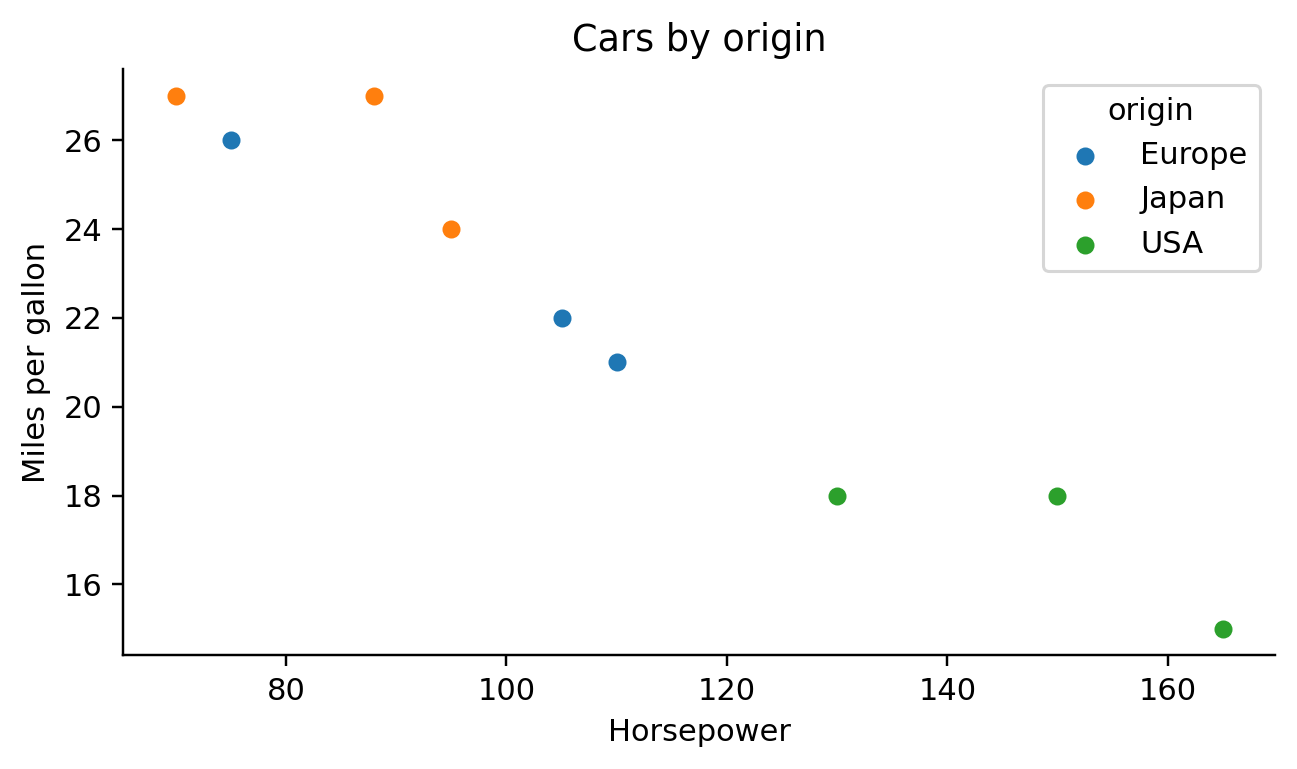

In [5]:
spec_scatter_color = {
    "data": {"values": [
        {"hp": 130, "mpg": 18.0, "origin": "USA"},
        {"hp": 165, "mpg": 15.0, "origin": "USA"},
        {"hp": 150, "mpg": 18.0, "origin": "USA"},
        {"hp": 95,  "mpg": 24.0, "origin": "Japan"},
        {"hp": 70,  "mpg": 27.0, "origin": "Japan"},
        {"hp": 88,  "mpg": 27.0, "origin": "Japan"},
        {"hp": 75,  "mpg": 26.0, "origin": "Europe"},
        {"hp": 105, "mpg": 22.0, "origin": "Europe"},
        {"hp": 110, "mpg": 21.0, "origin": "Europe"},
    ]},
    "mark": "point",
    "encoding": {
        "x": {"field": "hp", "type": "quantitative", "title": "Horsepower"},
        "y": {"field": "mpg", "type": "quantitative", "title": "Miles per gallon"},
        "color": {"field": "origin", "type": "nominal"},
    },
    "title": "Cars by origin",
}
show_side_by_side(spec_scatter_color)

## Example 4: line chart with grouped series

--- generated Matplotlib code ---
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

fig, ax = plt.subplots(figsize=(6, 3.6))

df = pd.DataFrame([{"month": "Jan", "city": "Bengaluru", "rainfall_mm": 2}, {"month": "Feb", "city": "Bengaluru", "rainfall_mm": 6}, {"month": "Mar", "city": "Bengaluru", "rainfall_mm": 11}, {"month": "Apr", "city": "Bengaluru", "rainfall_mm": 38}, {"month": "May", "city": "Bengaluru", "rainfall_mm": 105}, {"month": "Jun", "city": "Bengaluru", "rainfall_mm": 88}, {"month": "Jan", "city": "Mumbai", "rainfall_mm": 0}, {"month": "Feb", "city": "Mumbai", "rainfall_mm": 0}, {"month": "Mar", "city": "Mumbai", "rainfall_mm": 0}, {"month": "Apr", "city": "Mumbai", "rainfall_mm": 1}, {"month": "May", "city": "Mumbai", "rainfall_mm": 12}, {"month": "Jun", "city": "Mumbai", "rainfall_mm": 540}])
for label, sub in df.groupby('city'):
    ax.plot(sub['month'], sub['rainfall_mm'], marker='o', label=label)
ax.legend(title='city')
ax.set_xlabel('Month')
ax

alt.Chart(...)

--- Matplotlib render of the generated code ---


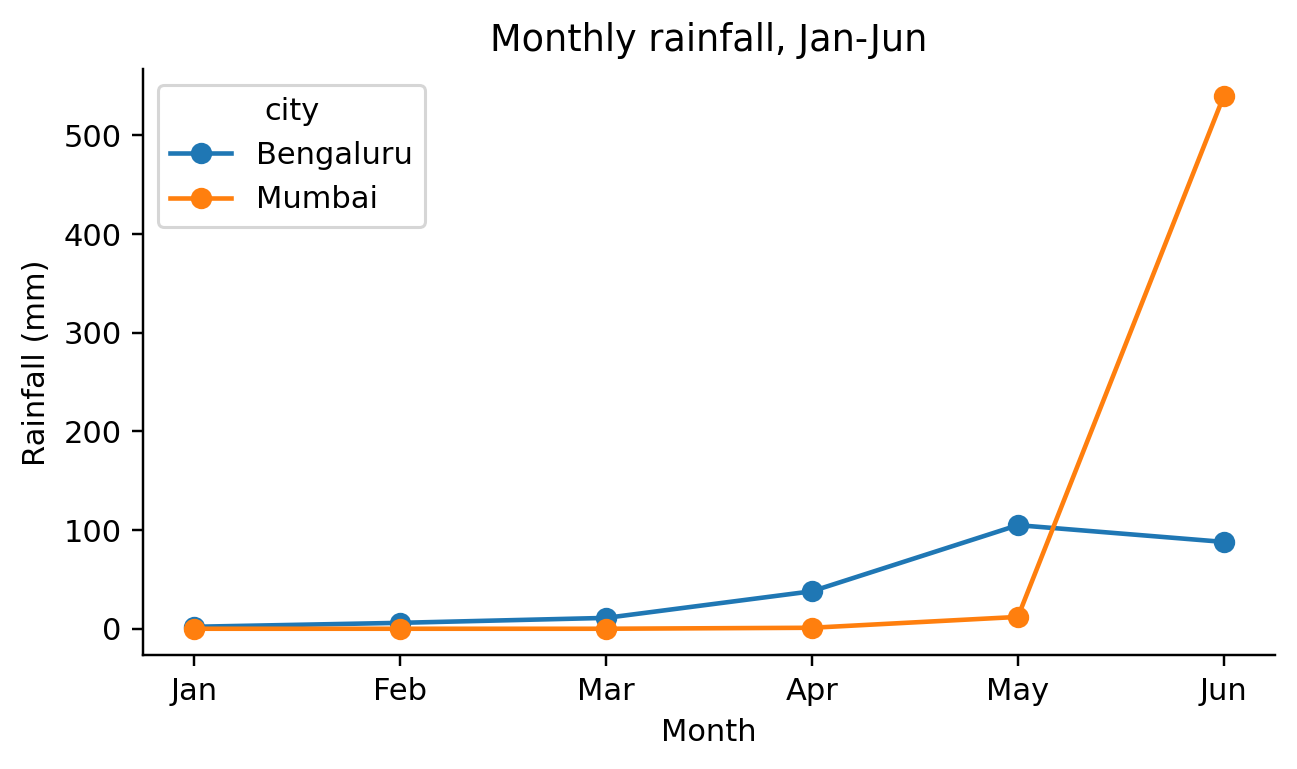

In [6]:
spec_line = {
    "data": {"values": [
        {"month": "Jan", "city": "Bengaluru", "rainfall_mm": 2},
        {"month": "Feb", "city": "Bengaluru", "rainfall_mm": 6},
        {"month": "Mar", "city": "Bengaluru", "rainfall_mm": 11},
        {"month": "Apr", "city": "Bengaluru", "rainfall_mm": 38},
        {"month": "May", "city": "Bengaluru", "rainfall_mm": 105},
        {"month": "Jun", "city": "Bengaluru", "rainfall_mm": 88},
        {"month": "Jan", "city": "Mumbai", "rainfall_mm": 0},
        {"month": "Feb", "city": "Mumbai", "rainfall_mm": 0},
        {"month": "Mar", "city": "Mumbai", "rainfall_mm": 0},
        {"month": "Apr", "city": "Mumbai", "rainfall_mm": 1},
        {"month": "May", "city": "Mumbai", "rainfall_mm": 12},
        {"month": "Jun", "city": "Mumbai", "rainfall_mm": 540},
    ]},
    "mark": "line",
    "encoding": {
        "x": {"field": "month", "type": "ordinal", "title": "Month"},
        "y": {"field": "rainfall_mm", "type": "quantitative", "title": "Rainfall (mm)"},
        "color": {"field": "city", "type": "nominal"},
    },
    "title": "Monthly rainfall, Jan-Jun",
}
show_side_by_side(spec_line)

## Example 5: grouped bars

--- generated Matplotlib code ---
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

fig, ax = plt.subplots(figsize=(6, 3.6))

df = pd.DataFrame([{"quarter": "Q1", "team": "A", "score": 12}, {"quarter": "Q2", "team": "A", "score": 17}, {"quarter": "Q3", "team": "A", "score": 9}, {"quarter": "Q4", "team": "A", "score": 14}, {"quarter": "Q1", "team": "B", "score": 8}, {"quarter": "Q2", "team": "B", "score": 19}, {"quarter": "Q3", "team": "B", "score": 15}, {"quarter": "Q4", "team": "B", "score": 11}])
groups = list(dict.fromkeys(df['team']))
x_vals = list(dict.fromkeys(df['quarter']))
x_idx = np.arange(len(x_vals))
width = 0.8 / max(1, len(groups))
for i, g in enumerate(groups):
    sub = df[df['team'] == g]
    ys = [sub[sub['quarter'] == xv]['score'].sum() for xv in x_vals]
    ax.bar(x_idx + i * width - 0.4 + width / 2, ys, width, label=str(g))
ax.set_xticks(x_idx)
ax.set_xticklabels(x_vals)
ax.legend(title='team')
ax.set_xlabel('Quarter')
ax.set_ylabel('Score')
a

alt.Chart(...)

--- Matplotlib render of the generated code ---


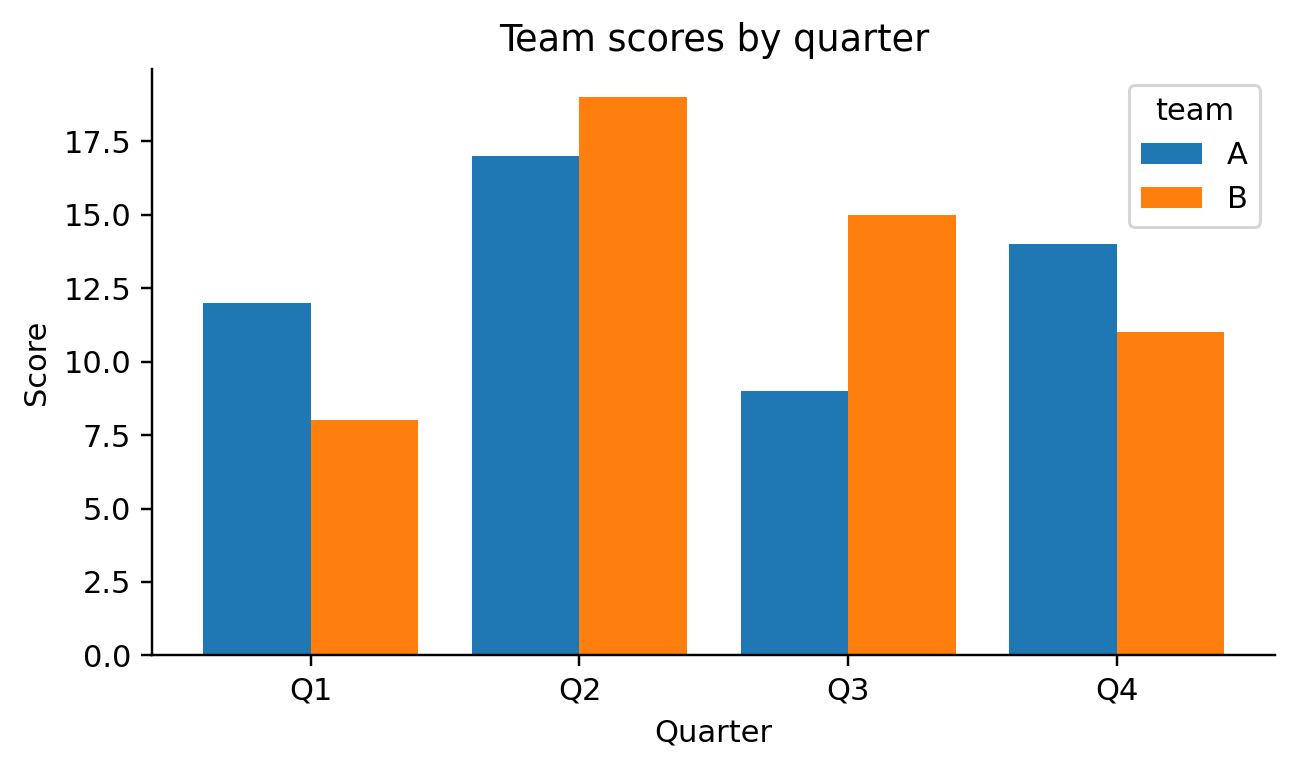

In [7]:
spec_grouped = {
    "data": {"values": [
        {"quarter": "Q1", "team": "A", "score": 12},
        {"quarter": "Q2", "team": "A", "score": 17},
        {"quarter": "Q3", "team": "A", "score": 9},
        {"quarter": "Q4", "team": "A", "score": 14},
        {"quarter": "Q1", "team": "B", "score": 8},
        {"quarter": "Q2", "team": "B", "score": 19},
        {"quarter": "Q3", "team": "B", "score": 15},
        {"quarter": "Q4", "team": "B", "score": 11},
    ]},
    "mark": "bar",
    "encoding": {
        "x": {"field": "quarter", "type": "nominal", "title": "Quarter"},
        "y": {"field": "score", "type": "quantitative", "title": "Score"},
        "color": {"field": "team", "type": "nominal"},
    },
    "title": "Team scores by quarter",
}
show_side_by_side(spec_grouped)

## Example 6: aggregated bar (`mean` over a group)

Vega-Lite encodings can carry an `aggregate` field. Here `y` says "average `mpg` per `origin`" — the visitor emits a `groupby(...).mean()` step before plotting and the axis label becomes `mean(mpg)`.

--- generated Matplotlib code ---
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

fig, ax = plt.subplots(figsize=(6, 3.6))

df = pd.DataFrame([{"origin": "USA", "mpg": 18.0}, {"origin": "USA", "mpg": 15.0}, {"origin": "USA", "mpg": 14.0}, {"origin": "USA", "mpg": 16.5}, {"origin": "Japan", "mpg": 27.0}, {"origin": "Japan", "mpg": 30.0}, {"origin": "Japan", "mpg": 25.0}, {"origin": "Europe", "mpg": 22.0}, {"origin": "Europe", "mpg": 19.0}, {"origin": "Europe", "mpg": 24.0}])
agg_df = df.groupby('origin')['mpg'].mean().reset_index()
ax.bar(agg_df['origin'], agg_df['mpg'])
ax.set_xlabel('Origin')
ax.set_ylabel('mean(mpg)')
ax.set_title('Average MPG by origin')
fig.tight_layout()
plt.show()

--- Altair render of the original spec ---


alt.Chart(...)

--- Matplotlib render of the generated code ---


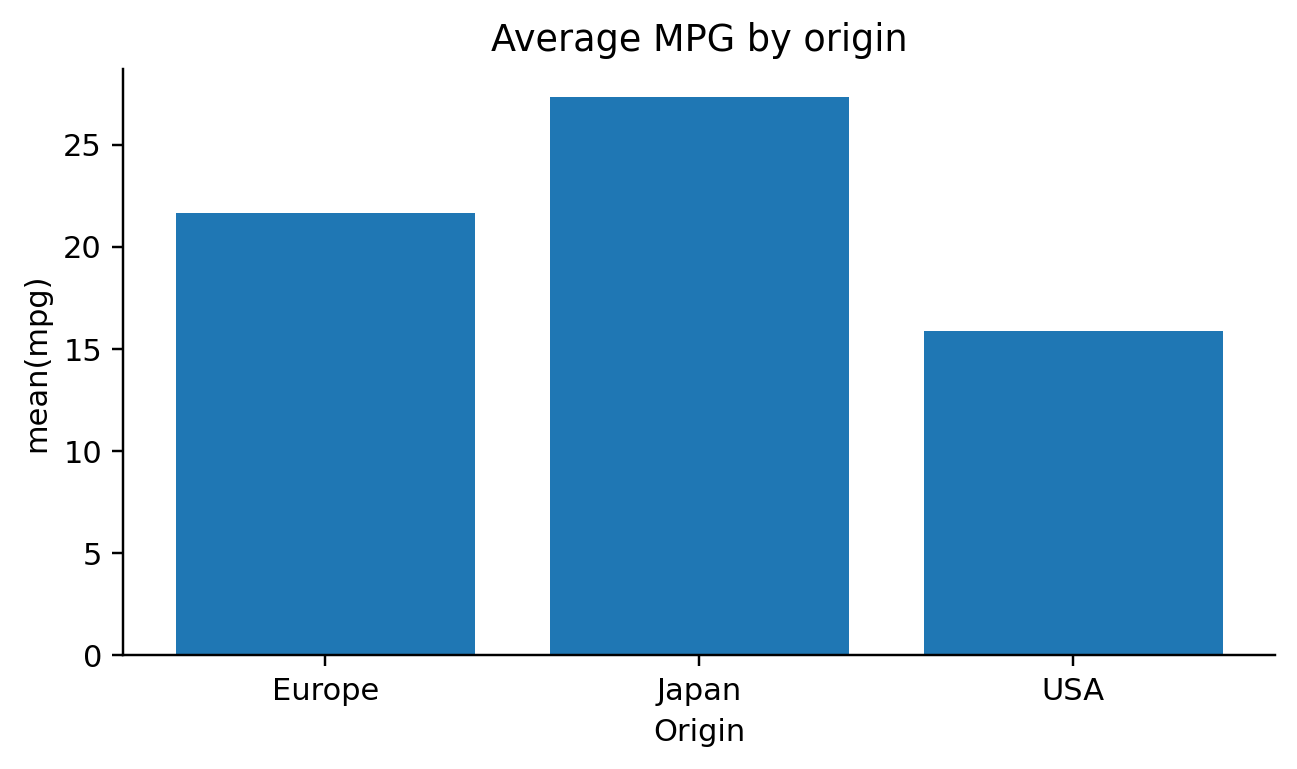

In [8]:
spec_agg_bar = {
    "data": {"values": [
        {"origin": "USA",    "mpg": 18.0},
        {"origin": "USA",    "mpg": 15.0},
        {"origin": "USA",    "mpg": 14.0},
        {"origin": "USA",    "mpg": 16.5},
        {"origin": "Japan",  "mpg": 27.0},
        {"origin": "Japan",  "mpg": 30.0},
        {"origin": "Japan",  "mpg": 25.0},
        {"origin": "Europe", "mpg": 22.0},
        {"origin": "Europe", "mpg": 19.0},
        {"origin": "Europe", "mpg": 24.0},
    ]},
    "mark": "bar",
    "encoding": {
        "x": {"field": "origin", "type": "nominal", "title": "Origin"},
        "y": {"field": "mpg", "type": "quantitative", "aggregate": "mean"},
    },
    "title": "Average MPG by origin",
}
show_side_by_side(spec_agg_bar)

## Example 7: log-scale axes plus a size channel

The visitor reads `scale: {"type": "log"}` from the `x` encoding and emits `ax.set_xscale('log')`. The `size` channel maps a numeric field to scatter point size with a normalized scaling.

--- generated Matplotlib code ---
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

fig, ax = plt.subplots(figsize=(6, 3.6))

df = pd.DataFrame([{"gdp_per_capita": 1500, "life_expectancy": 60, "population": 1500000000.0}, {"gdp_per_capita": 2200, "life_expectancy": 67, "population": 1400000000.0}, {"gdp_per_capita": 8000, "life_expectancy": 73, "population": 210000000.0}, {"gdp_per_capita": 12000, "life_expectancy": 76, "population": 52000000.0}, {"gdp_per_capita": 35000, "life_expectancy": 82, "population": 130000000.0}, {"gdp_per_capita": 45000, "life_expectancy": 81, "population": 85000000.0}, {"gdp_per_capita": 65000, "life_expectancy": 82, "population": 330000000.0}])
ax.scatter(df['gdp_per_capita'], df['life_expectancy'], s=(df['population'] / max(1.0, df['population'].max())) * 200 + 8)
ax.set_xlabel('GDP per capita (log)')
ax.set_xscale('log')
ax.set_ylabel('Life expectancy (years)')
ax.set_title('Hans-Rosling-ish')
fig.tight_layout()
plt.show()

--- Altai

alt.Chart(...)

--- Matplotlib render of the generated code ---


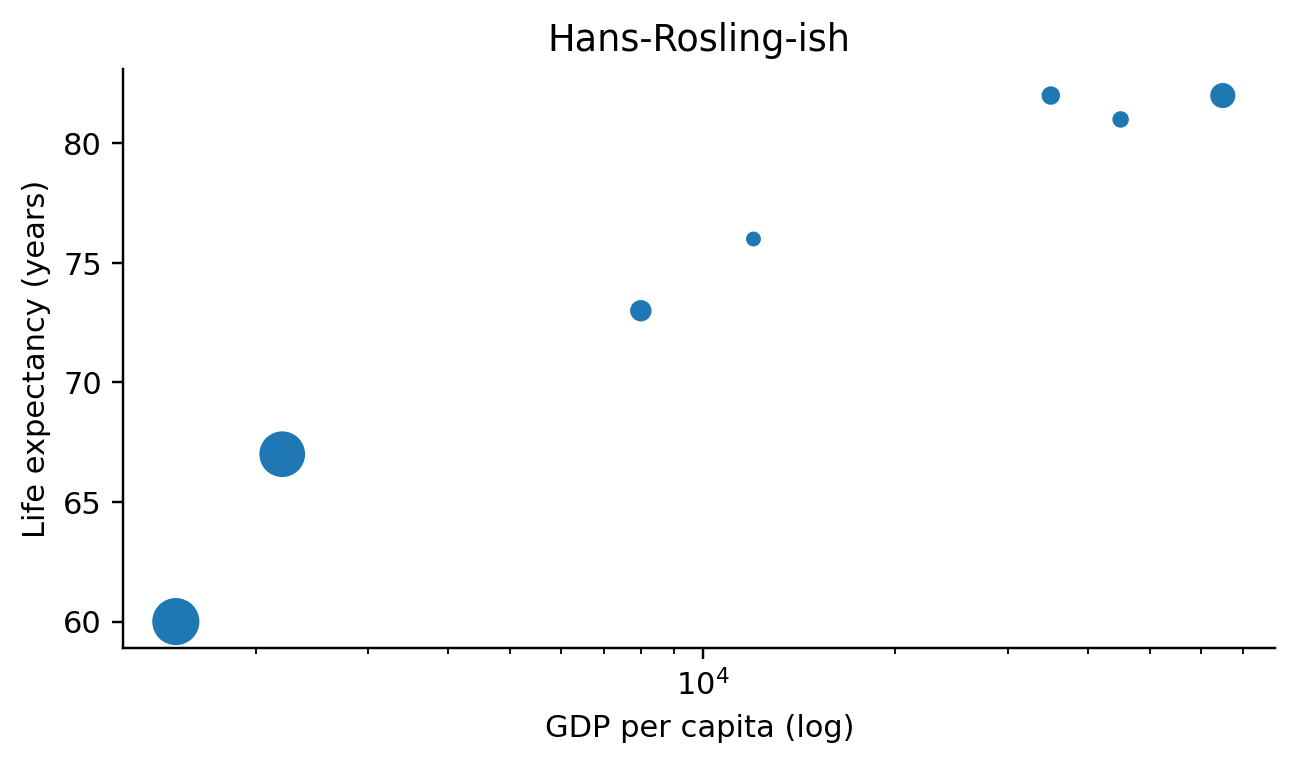

In [9]:
spec_log_size = {
    "data": {"values": [
        {"gdp_per_capita": 1500,  "life_expectancy": 60, "population": 1.5e9},
        {"gdp_per_capita": 2200,  "life_expectancy": 67, "population": 1.4e9},
        {"gdp_per_capita": 8000,  "life_expectancy": 73, "population": 2.1e8},
        {"gdp_per_capita": 12000, "life_expectancy": 76, "population": 5.2e7},
        {"gdp_per_capita": 35000, "life_expectancy": 82, "population": 1.3e8},
        {"gdp_per_capita": 45000, "life_expectancy": 81, "population": 8.5e7},
        {"gdp_per_capita": 65000, "life_expectancy": 82, "population": 3.3e8},
    ]},
    "mark": "circle",
    "encoding": {
        "x": {"field": "gdp_per_capita", "type": "quantitative",
              "scale": {"type": "log"}, "title": "GDP per capita (log)"},
        "y": {"field": "life_expectancy", "type": "quantitative",
              "title": "Life expectancy (years)"},
        "size": {"field": "population", "type": "quantitative"},
    },
    "title": "Hans-Rosling-ish",
}
show_side_by_side(spec_log_size)

## Example 8: layered chart (scatter + trend line)

A `layer` block combines two unit specs into one Matplotlib axes. The visitor walks each layer, emits its own dataframe + transform + mark, and shares the axes. We pass a separate dataframe for the trend line so the demo doesn't need an extra regression step.

--- generated Matplotlib code ---
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

fig, ax = plt.subplots(figsize=(6, 3.6))

df_layer_0 = pd.DataFrame([{"x": 1, "y": 2.1}, {"x": 2, "y": 3.7}, {"x": 3, "y": 5.0}, {"x": 4, "y": 7.2}, {"x": 5, "y": 8.6}, {"x": 6, "y": 10.4}, {"x": 7, "y": 12.0}, {"x": 8, "y": 13.7}])
ax.scatter(df_layer_0['x'], df_layer_0['y'], s=24)
df_layer_1 = pd.DataFrame([{"x": 1, "y_pred": 2.0}, {"x": 8, "y_pred": 14.0}])
ax.plot(df_layer_1['x'], df_layer_1['y_pred'], marker='o')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Observations + linear trend')
fig.tight_layout()
plt.show()

--- Altair render of the original spec ---


alt.LayerChart(...)

--- Matplotlib render of the generated code ---


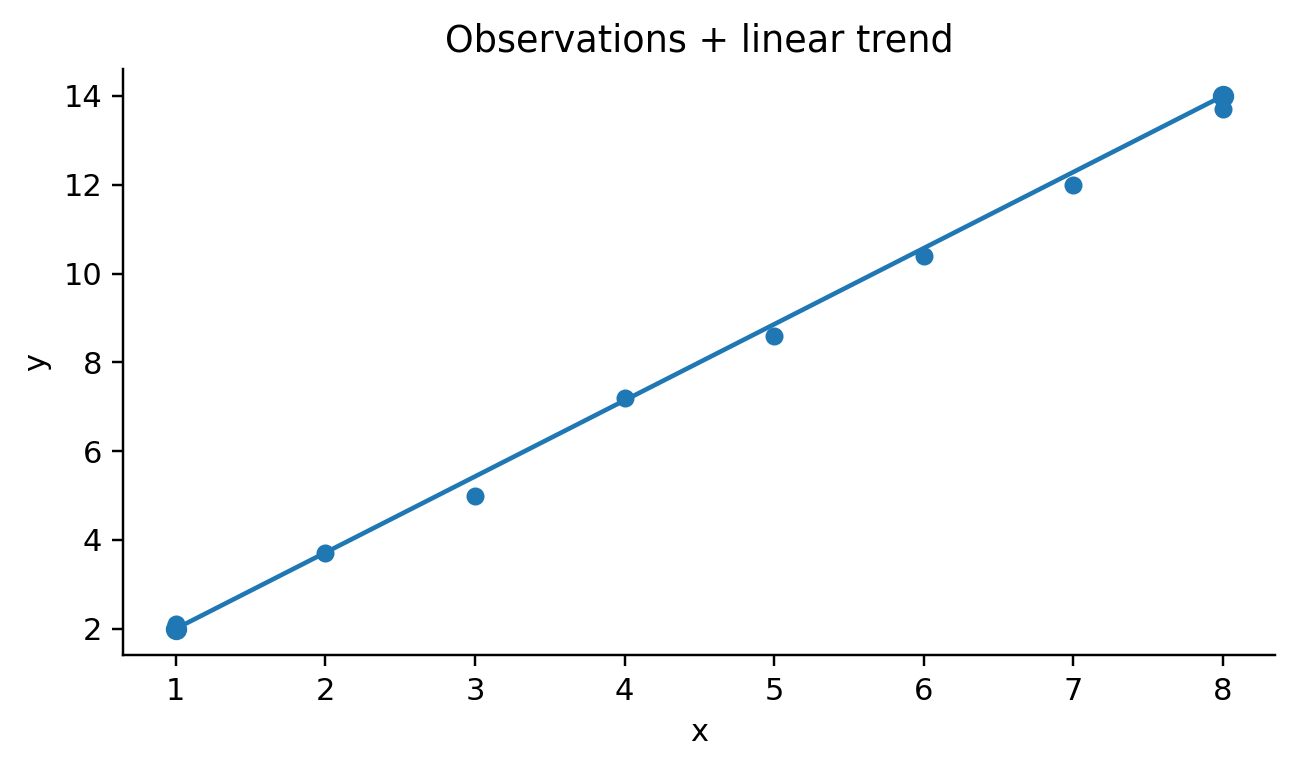

In [10]:
spec_layer = {
    "data": {"values": [
        {"x": 1, "y": 2.1}, {"x": 2, "y": 3.7}, {"x": 3, "y": 5.0},
        {"x": 4, "y": 7.2}, {"x": 5, "y": 8.6}, {"x": 6, "y": 10.4},
        {"x": 7, "y": 12.0}, {"x": 8, "y": 13.7},
    ]},
    "layer": [
        {"mark": "point",
         "encoding": {
             "x": {"field": "x", "type": "quantitative", "title": "x"},
             "y": {"field": "y", "type": "quantitative", "title": "y"},
         }},
        {"data": {"values": [
            {"x": 1, "y_pred": 2.0}, {"x": 8, "y_pred": 14.0},
         ]},
         "mark": "line",
         "encoding": {
             "x": {"field": "x", "type": "quantitative"},
             "y": {"field": "y_pred", "type": "quantitative"},
         }},
    ],
    "title": "Observations + linear trend",
}
show_side_by_side(spec_layer)

## Example 9: faceted small multiples

A `column` encoding triggers `visit_facet`: the visitor builds a 1xN grid of `Axes` objects, recurses with each subset of the dataframe, and titles each panel.

--- generated Matplotlib code ---
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = pd.DataFrame([{"region": "North", "category": "A", "value": 12}, {"region": "North", "category": "B", "value": 22}, {"region": "North", "category": "C", "value": 9}, {"region": "South", "category": "A", "value": 6}, {"region": "South", "category": "B", "value": 18}, {"region": "South", "category": "C", "value": 15}, {"region": "West", "category": "A", "value": 11}, {"region": "West", "category": "B", "value": 14}, {"region": "West", "category": "C", "value": 19}])
facet_values = list(dict.fromkeys(df['region']))
fig, axes = plt.subplots(
    1, len(facet_values),
    figsize=(3.0 * len(facet_values), 3.2),
    sharey=True,
)
if len(facet_values) == 1:
    axes = [axes]
for ax, facet_val in zip(axes, facet_values):
    sub = df[df['region'] == facet_val]
    ax.bar(sub['category'], sub['value'])
    ax.set_xlabel('Category')
    ax.set_ylabel('Value')
    ax.set_title('Small mu

alt.Chart(...)

--- Matplotlib render of the generated code ---


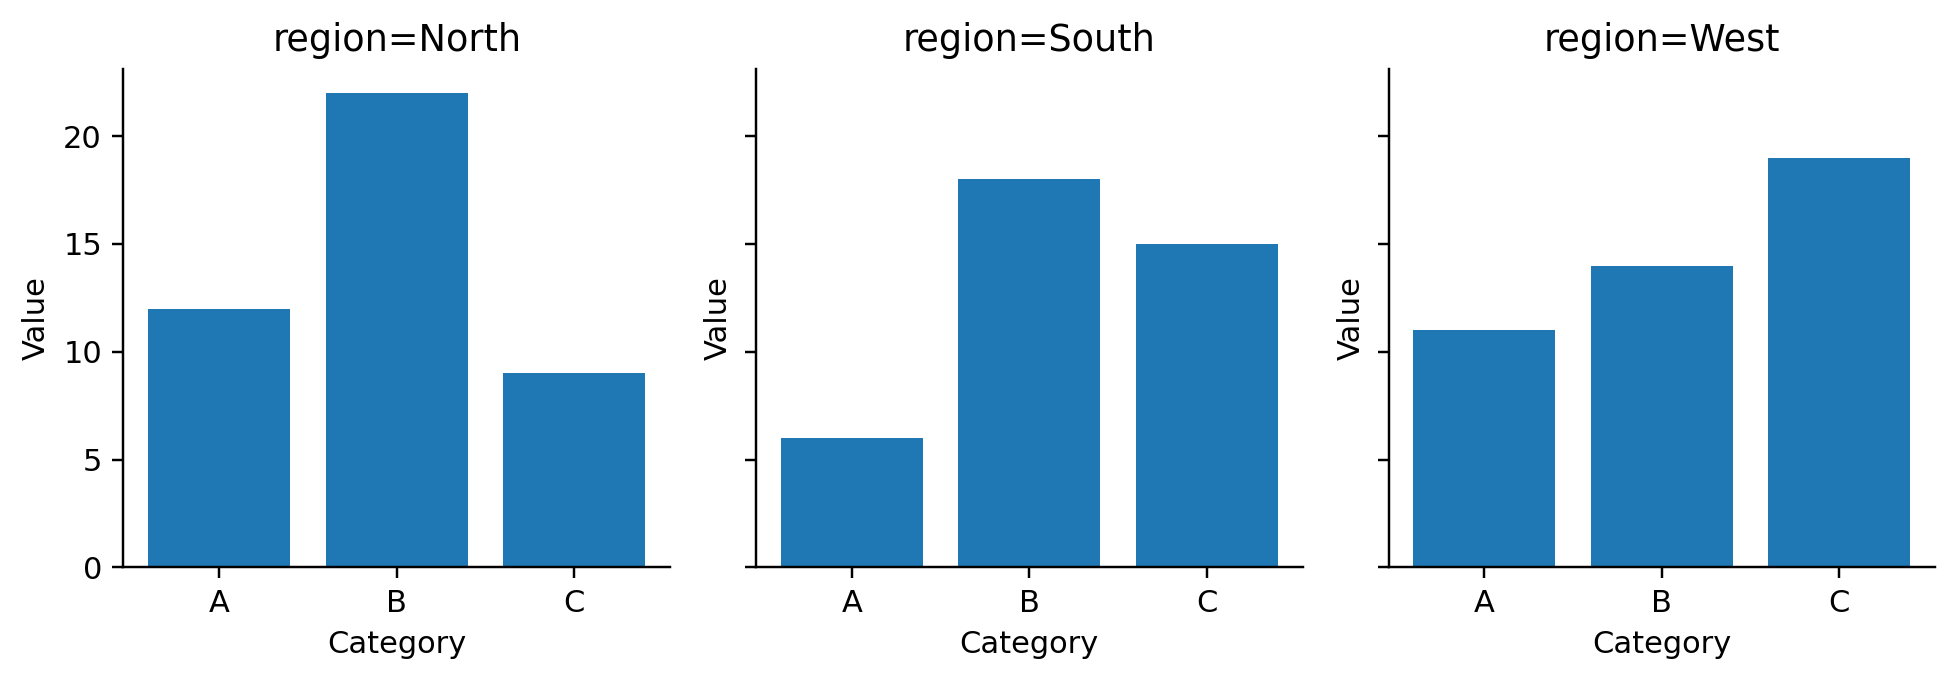

In [11]:
spec_facet = {
    "data": {"values": [
        {"region": "North", "category": "A", "value": 12},
        {"region": "North", "category": "B", "value": 22},
        {"region": "North", "category": "C", "value": 9},
        {"region": "South", "category": "A", "value": 6},
        {"region": "South", "category": "B", "value": 18},
        {"region": "South", "category": "C", "value": 15},
        {"region": "West",  "category": "A", "value": 11},
        {"region": "West",  "category": "B", "value": 14},
        {"region": "West",  "category": "C", "value": 19},
    ]},
    "mark": "bar",
    "encoding": {
        "x": {"field": "category", "type": "nominal", "title": "Category"},
        "y": {"field": "value", "type": "quantitative", "title": "Value"},
        "column": {"field": "region", "type": "nominal"},
    },
    "title": "Small multiples by region",
}
show_side_by_side(spec_facet)

## Example 10: a `filter` transform

`transform: [{"filter": "datum.x > 5"}]` is rewritten into a pandas boolean mask. The string is rewritten naively (`datum.` → `df.`), which is good enough for simple boolean expressions.

--- generated Matplotlib code ---
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

fig, ax = plt.subplots(figsize=(6, 3.6))

df = pd.DataFrame([{"x": 1, "y": 1.7}, {"x": 2, "y": 3.4}, {"x": 3, "y": 5.1}, {"x": 4, "y": 6.8}, {"x": 5, "y": 8.5}, {"x": 6, "y": 10.2}, {"x": 7, "y": 0.9000000000000004}, {"x": 8, "y": 2.5999999999999996}, {"x": 9, "y": 4.299999999999999}, {"x": 10, "y": 6.0}, {"x": 11, "y": 7.699999999999999}, {"x": 12, "y": 9.399999999999999}, {"x": 13, "y": 0.09999999999999787}, {"x": 14, "y": 1.8000000000000007}, {"x": 15, "y": 3.5}])
df = df[df.x > 5].reset_index(drop=True)
ax.scatter(df['x'], df['y'], s=24)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Only x > 5 survives the filter')
fig.tight_layout()
plt.show()

--- Altair render of the original spec ---


alt.Chart(...)

--- Matplotlib render of the generated code ---


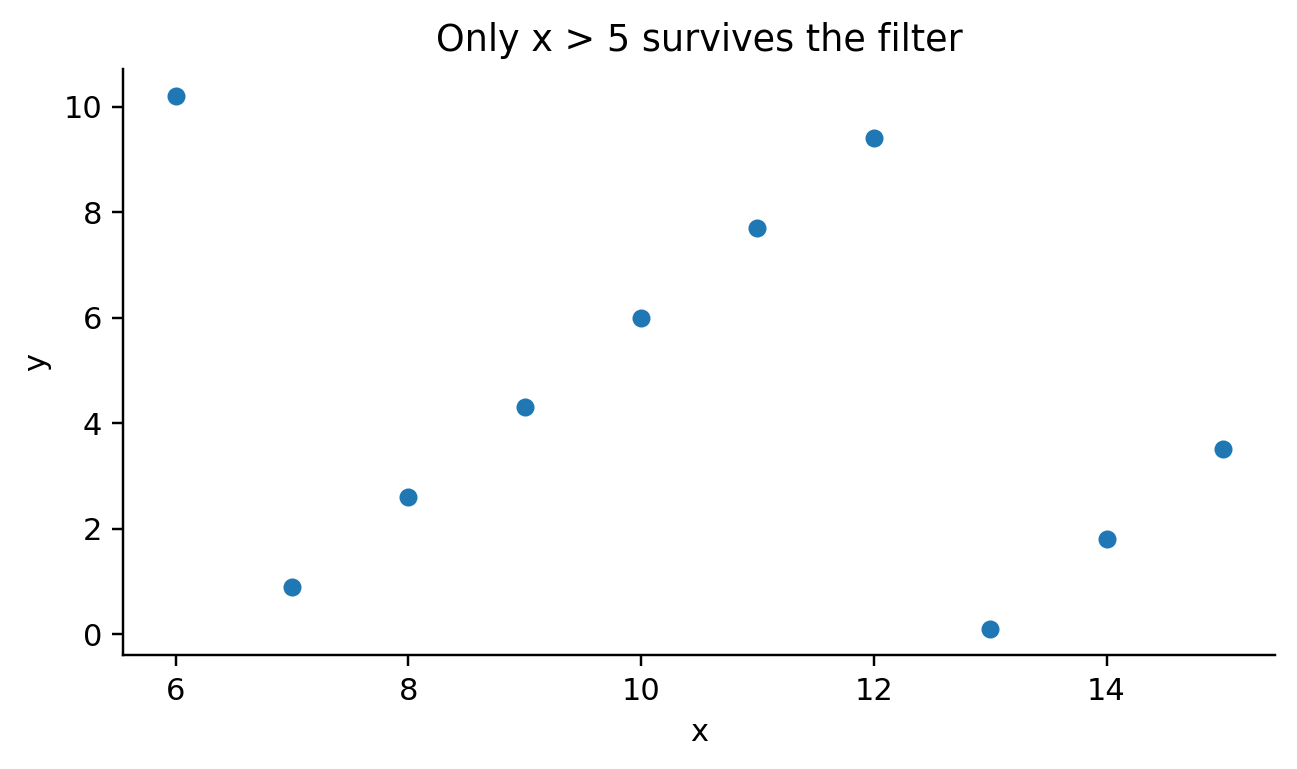

In [12]:
spec_filter = {
    "data": {"values": [
        {"x": i, "y": (i * 1.7) % 11} for i in range(1, 16)
    ]},
    "transform": [{"filter": "datum.x > 5"}],
    "mark": "point",
    "encoding": {
        "x": {"field": "x", "type": "quantitative"},
        "y": {"field": "y", "type": "quantitative"},
    },
    "title": "Only x > 5 survives the filter",
}
show_side_by_side(spec_filter)

## Example 11: `area` and `tick` marks

Two marks the visitor learned in v2. `area` uses `fill_between`; `tick` uses a vertical-bar marker, optionally over a y axis when given.

--- generated Matplotlib code ---
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

fig, ax = plt.subplots(figsize=(6, 3.6))

df = pd.DataFrame([{"t": 0, "v": 1.0}, {"t": 1, "v": 2.4}, {"t": 2, "v": 3.1}, {"t": 3, "v": 2.6}, {"t": 4, "v": 3.9}, {"t": 5, "v": 5.0}])
ax.fill_between(df['t'], df['v'], alpha=0.4)
ax.plot(df['t'], df['v'])
ax.set_xlabel('t')
ax.set_ylabel('v')
ax.set_title('Area under a tiny curve')
fig.tight_layout()
plt.show()

--- Altair render of the original spec ---


alt.Chart(...)

--- Matplotlib render of the generated code ---


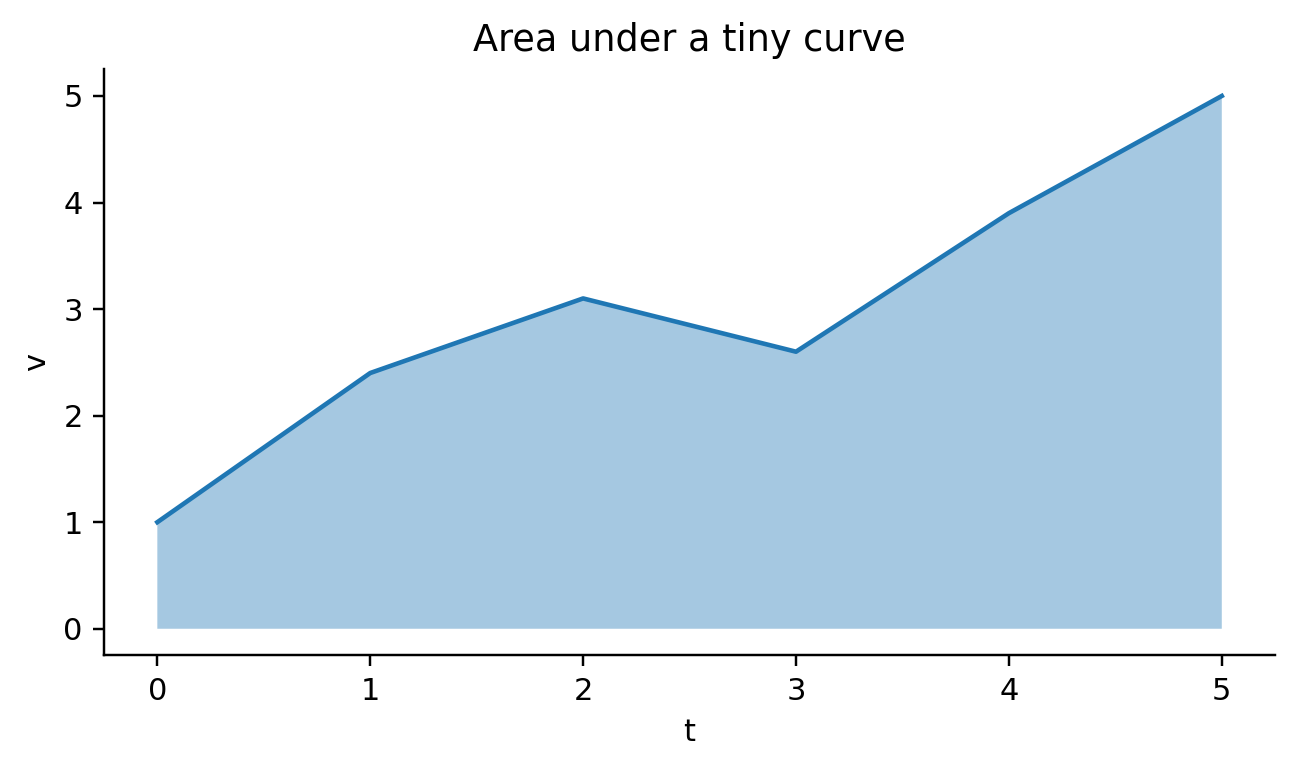

--- generated Matplotlib code ---
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

fig, ax = plt.subplots(figsize=(6, 3.6))

df = pd.DataFrame([{"x": 0.4}, {"x": 0.9}, {"x": 1.1}, {"x": 1.7}, {"x": 2.0}, {"x": 2.3}, {"x": 2.4}, {"x": 2.9}, {"x": 3.5}, {"x": 4.1}, {"x": 4.6}])
ax.scatter(df['x'], np.zeros(len(df)), marker='|', s=180)
ax.set_yticks([])
ax.set_xlabel('x')
ax.set_title('1-D distribution')
fig.tight_layout()
plt.show()

--- Altair render of the original spec ---


alt.Chart(...)

--- Matplotlib render of the generated code ---


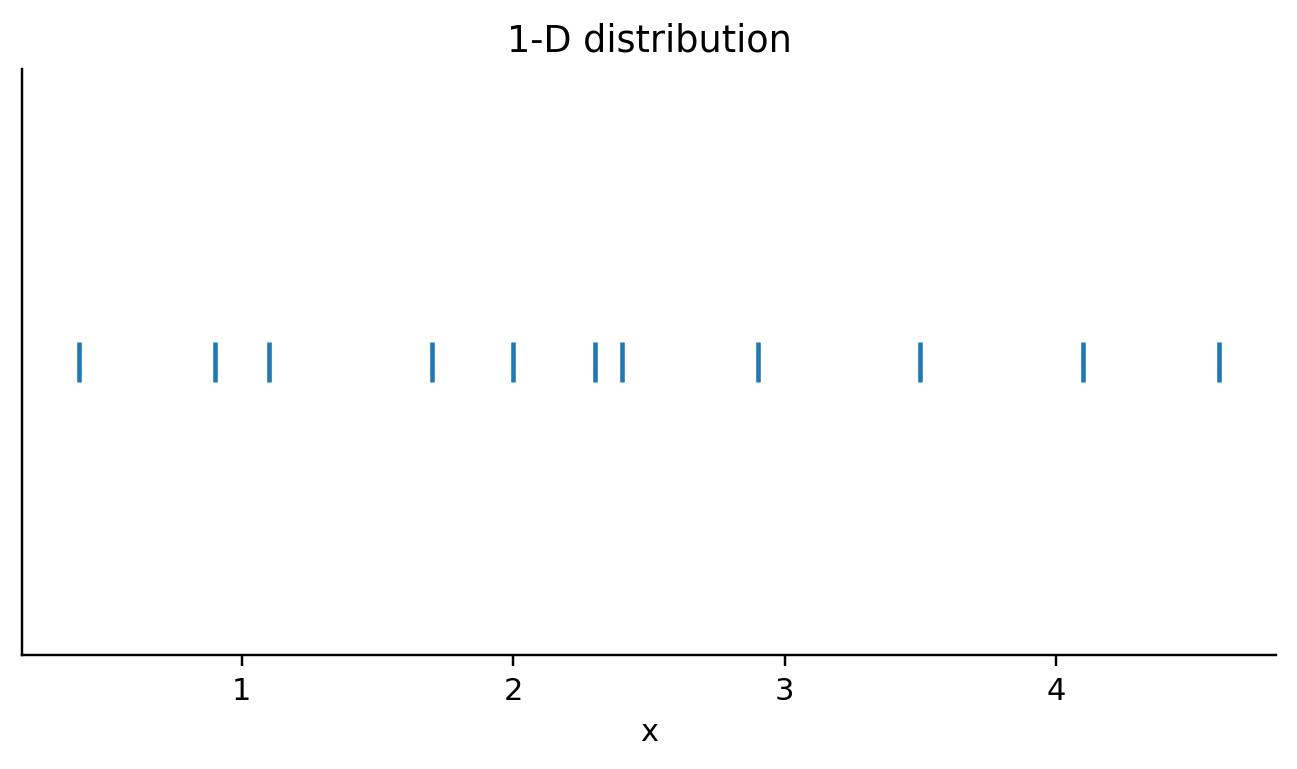

In [13]:
spec_area = {
    "data": {"values": [
        {"t": 0, "v": 1.0}, {"t": 1, "v": 2.4}, {"t": 2, "v": 3.1},
        {"t": 3, "v": 2.6}, {"t": 4, "v": 3.9}, {"t": 5, "v": 5.0},
    ]},
    "mark": "area",
    "encoding": {
        "x": {"field": "t", "type": "quantitative", "title": "t"},
        "y": {"field": "v", "type": "quantitative", "title": "v"},
    },
    "title": "Area under a tiny curve",
}
show_side_by_side(spec_area)

spec_tick = {
    "data": {"values": [
        {"x": v} for v in [0.4, 0.9, 1.1, 1.7, 2.0, 2.3, 2.4, 2.9, 3.5, 4.1, 4.6]
    ]},
    "mark": "tick",
    "encoding": {"x": {"field": "x", "type": "quantitative", "title": "x"}},
    "title": "1-D distribution",
}
show_side_by_side(spec_tick)

## Robustness: explicit errors when something is unsupported

Passing a mark the visitor doesn't know about raises a clear `NotImplementedError`. This is the v2 robustness story: instead of silently emitting broken code or `KeyError`-ing partway through, the translator stops at the first node it can't handle and tells you which one.

In [14]:
spec_unsupported = {
    "data": {"values": [{"x": 1, "y": 2}]},
    "mark": "rule",  # not in the supported set
    "encoding": {
        "x": {"field": "x", "type": "quantitative"},
        "y": {"field": "y", "type": "quantitative"},
    },
}
try:
    vegalite_to_matplotlib(spec_unsupported)
except NotImplementedError as e:
    print("translator stopped cleanly:", e)

translator stopped cleanly: mark 'rule' not supported


## Still out of scope

- **`hconcat` / `vconcat` of arbitrary unit specs** — the visitor handles `column`/`row` faceting where each panel is the same shape, but freely concatenated panels need a more general grid builder.
- **Time scales.** Vega-Lite's `temporal` type would map to `matplotlib.dates`. Easy to wire up via `_emit_axes`.
- **Named color schemes (`category10`, `viridis`).** Map them to Matplotlib `cmap`s in a small lookup.
- **Tooltips, selections, parameters.** No analogue in static Matplotlib.
- **Resolved scales / shared legends across complex layered+faceted specs.** Real compiler territory.

The shape of the visitor makes all of these additive: each is a new method or a new branch in `_emit_axes`, not a rewrite.

## Closing thought

The first version of this translator was a single function with a stack of `if mark == "x"` branches. That was fine while there were only five marks. The moment the spec language acquired structure (layers, facets, transforms), the function had to acquire structure too — and the visitor pattern gives that structure for almost free. One method per node type, recursion for containers, dispatch via `getattr` for marks.

The bigger point: a plot DSL like Vega-Lite is just a tree, and translating it to Matplotlib is just a tree walk that emits Python source. The hard parts of dataviz aren't in either DSL — they're in *the choices about what to plot*. Once you've made those choices, lowering them onto whichever backend you need is a couple hundred lines of switch statements.